### 1.Data Cleaning 

In [2]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snp
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro

# import data set
df=pd.read_csv(r"C:\Users\DIPAK\Downloads\ecommerce_messy_dataset.csv")

In [3]:
# Load the data set
df

,S,Customer_ID,Order_Date,Product,Category,Price,Quantity,Discount,Sales,Profit,Payment_Method,City,Region,Order_Status
0,ORD000001,C00190,24-04-2025,Book,Books,1012.65,3,5,2882.05,-288.21,PayPal,Mumbai,West,Returned
1,ORD000002,C03700,02-05-2024,Headphones,Fashion,102.07,6,10,551.18,55.12,COD,Bengaluru,South,Cancelled
2,ORD000003,C10807,06-19-2024,Laptop,Books,66.44,9,20,478.37,47.84,COD,Delhi,West,Delivered
3,ORD000004,C06132,22-03-2025,Laptop,Books,777.24,1,10,699.52,139.90,PayPal,Vadodara,West,Pending
4,ORD000005,C10121,19-04-2025,Headphones,Fashion,51.24,5,10,230.58,23.06,PayPal,Bengaluru,West,Delivered
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,C13795,28-05-2024,Headphones,Electronics,NaN,1,0,NaN,NaN,PayPal,Bengaluru,South,Returned
99996,ORD099997,C08221,19-03-2024,Phone,Books,867.14,6,20,4162.27,416.23,PayPal,Bengaluru,South,Delivered
99997,ORD099998,C05481,19-07-2025,Shoes,Fashion,NaN,4,10,NaN,NaN,UPI,Vadodara,North,Delivered
99998,ORD099999,C02531,20-08-2025,Shoes,Books,NaN,5,20,NaN,NaN,COD,Bengaluru,North,Delivered


In [4]:
# data set information and shape
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   S               100000 non-null  str    
 1   Customer_ID     100000 non-null  str    
 2   Order_Date      100000 non-null  str    
 3   Product         100000 non-null  str    
 4   Category        100000 non-null  str    
 5   Price           95008 non-null   float64
 6   Quantity        100000 non-null  int64  
 7   Discount        100000 non-null  int64  
 8   Sales           95008 non-null   float64
 9   Profit          95008 non-null   float64
 10  Payment_Method  100000 non-null  str    
 11  City            100000 non-null  str    
 12  Region          100000 non-null  str    
 13  Order_Status    100000 non-null  str    
dtypes: float64(3), int64(2), str(9)
memory usage: 10.7 MB


(100000, 14)

In [5]:
# Rename the Column Name
df.rename(columns={'S':'Serial_Number'},inplace=True)

In [6]:
# Profit Column negative values to convert positive vales using ABS 
df['Profit']=df['Profit'].abs()

In [7]:
# Sales Column negative values to convert positive vales using ABS 
df['Sales']=df['Sales'].abs()

In [8]:
# Price Column negative values to convert positive vales using ABS 
df['Price']=df['Price'].abs()

In [9]:
# load the dataset
df

,Serial_Number,Customer_ID,Order_Date,Product,Category,Price,Quantity,Discount,Sales,Profit,Payment_Method,City,Region,Order_Status
0,ORD000001,C00190,24-04-2025,Book,Books,1012.65,3,5,2882.05,288.21,PayPal,Mumbai,West,Returned
1,ORD000002,C03700,02-05-2024,Headphones,Fashion,102.07,6,10,551.18,55.12,COD,Bengaluru,South,Cancelled
2,ORD000003,C10807,06-19-2024,Laptop,Books,66.44,9,20,478.37,47.84,COD,Delhi,West,Delivered
3,ORD000004,C06132,22-03-2025,Laptop,Books,777.24,1,10,699.52,139.90,PayPal,Vadodara,West,Pending
4,ORD000005,C10121,19-04-2025,Headphones,Fashion,51.24,5,10,230.58,23.06,PayPal,Bengaluru,West,Delivered
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,C13795,28-05-2024,Headphones,Electronics,NaN,1,0,NaN,NaN,PayPal,Bengaluru,South,Returned
99996,ORD099997,C08221,19-03-2024,Phone,Books,867.14,6,20,4162.27,416.23,PayPal,Bengaluru,South,Delivered
99997,ORD099998,C05481,19-07-2025,Shoes,Fashion,NaN,4,10,NaN,NaN,UPI,Vadodara,North,Delivered
99998,ORD099999,C02531,20-08-2025,Shoes,Books,NaN,5,20,NaN,NaN,COD,Bengaluru,North,Delivered


In [10]:
# No Duplicate Rows in this Dataset
df.duplicated().sum()

np.int64(0)

In [11]:
# Price column fill values using fillna
df['Price']=df['Price'].fillna(df['Price'].median(),inplace=True)

C:\Users\DIPAK\AppData\Local\Temp\ipykernel_12428\1711548497.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Price']=df['Price'].fillna(df['Price'].median(),inplace=True)


In [12]:
# Load the data set
df

,Serial_Number,Customer_ID,Order_Date,Product,Category,Price,Quantity,Discount,Sales,Profit,Payment_Method,City,Region,Order_Status
0,ORD000001,C00190,24-04-2025,Book,Books,1012.65,3,5,2882.05,288.21,PayPal,Mumbai,West,Returned
1,ORD000002,C03700,02-05-2024,Headphones,Fashion,102.07,6,10,551.18,55.12,COD,Bengaluru,South,Cancelled
2,ORD000003,C10807,06-19-2024,Laptop,Books,66.44,9,20,478.37,47.84,COD,Delhi,West,Delivered
3,ORD000004,C06132,22-03-2025,Laptop,Books,777.24,1,10,699.52,139.90,PayPal,Vadodara,West,Pending
4,ORD000005,C10121,19-04-2025,Headphones,Fashion,51.24,5,10,230.58,23.06,PayPal,Bengaluru,West,Delivered
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,C13795,28-05-2024,Headphones,Electronics,1007.51,1,0,NaN,NaN,PayPal,Bengaluru,South,Returned
99996,ORD099997,C08221,19-03-2024,Phone,Books,867.14,6,20,4162.27,416.23,PayPal,Bengaluru,South,Delivered
99997,ORD099998,C05481,19-07-2025,Shoes,Fashion,1007.51,4,10,NaN,NaN,UPI,Vadodara,North,Delivered
99998,ORD099999,C02531,20-08-2025,Shoes,Books,1007.51,5,20,NaN,NaN,COD,Bengaluru,North,Delivered


In [13]:
# find the Null values
df.isnull().sum()

Serial_Number        0
Customer_ID          0
Order_Date           0
Product              0
Category             0
Price                0
Quantity             0
Discount             0
Sales             4992
Profit            4992
Payment_Method       0
City                 0
Region               0
Order_Status         0
dtype: int64

In [14]:
# Sales column fill values using fillna 
df['Sales']=df['Sales'].fillna(df['Sales'].median(),inplace=True)

C:\Users\DIPAK\AppData\Local\Temp\ipykernel_12428\2232846071.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Sales']=df['Sales'].fillna(df['Sales'].median(),inplace=True)


In [15]:
# find the Null values
df.isnull().sum()

Serial_Number        0
Customer_ID          0
Order_Date           0
Product              0
Category             0
Price                0
Quantity             0
Discount             0
Sales                0
Profit            4992
Payment_Method       0
City                 0
Region               0
Order_Status         0
dtype: int64

In [16]:
# Profit column fill values using fillna 
df['Profit']=df['Profit'].fillna(df['Profit'].median(),inplace=True)

C:\Users\DIPAK\AppData\Local\Temp\ipykernel_12428\4156774432.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Profit']=df['Profit'].fillna(df['Profit'].median(),inplace=True)


In [17]:
# find the Null values
df.isnull().sum()

Serial_Number     0
Customer_ID       0
Order_Date        0
Product           0
Category          0
Price             0
Quantity          0
Discount          0
Sales             0
Profit            0
Payment_Method    0
City              0
Region            0
Order_Status      0
dtype: int64

In [18]:
# check the data types 
df.dtypes

Serial_Number         str
Customer_ID           str
Order_Date            str
Product               str
Category              str
Price             float64
Quantity            int64
Discount            int64
Sales             float64
Profit            float64
Payment_Method        str
City                  str
Region                str
Order_Status          str
dtype: object

In [19]:
# Multiple columns Change the data type
two_col=['Price','Discount','Sales','Profit']
df[two_col]=df[two_col].astype('float64')

In [20]:
# check the data type
df.dtypes

Serial_Number         str
Customer_ID           str
Order_Date            str
Product               str
Category              str
Price             float64
Quantity            int64
Discount          float64
Sales             float64
Profit            float64
Payment_Method        str
City                  str
Region                str
Order_Status          str
dtype: object

In [21]:
# Load the Data set
df

,Serial_Number,Customer_ID,Order_Date,Product,Category,Price,Quantity,Discount,Sales,Profit,Payment_Method,City,Region,Order_Status
0,ORD000001,C00190,24-04-2025,Book,Books,1012.65,3,5.0,2882.050,288.21,PayPal,Mumbai,West,Returned
1,ORD000002,C03700,02-05-2024,Headphones,Fashion,102.07,6,10.0,551.180,55.12,COD,Bengaluru,South,Cancelled
2,ORD000003,C10807,06-19-2024,Laptop,Books,66.44,9,20.0,478.370,47.84,COD,Delhi,West,Delivered
3,ORD000004,C06132,22-03-2025,Laptop,Books,777.24,1,10.0,699.520,139.90,PayPal,Vadodara,West,Pending
4,ORD000005,C10121,19-04-2025,Headphones,Fashion,51.24,5,10.0,230.580,23.06,PayPal,Bengaluru,West,Delivered
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,C13795,28-05-2024,Headphones,Electronics,1007.51,1,0.0,3799.175,468.71,PayPal,Bengaluru,South,Returned
99996,ORD099997,C08221,19-03-2024,Phone,Books,867.14,6,20.0,4162.270,416.23,PayPal,Bengaluru,South,Delivered
99997,ORD099998,C05481,19-07-2025,Shoes,Fashion,1007.51,4,10.0,3799.175,468.71,UPI,Vadodara,North,Delivered
99998,ORD099999,C02531,20-08-2025,Shoes,Books,1007.51,5,20.0,3799.175,468.71,COD,Bengaluru,North,Delivered


In [22]:
df.dtypes

Serial_Number         str
Customer_ID           str
Order_Date            str
Product               str
Category              str
Price             float64
Quantity            int64
Discount          float64
Sales             float64
Profit            float64
Payment_Method        str
City                  str
Region                str
Order_Status          str
dtype: object

In [41]:
# Date column change data type
df['Order_Date']=pd.to_datetime(df['Order_Date'],errors='coerce')

In [42]:
df.dropna(subset=['Order_Date'],inplace=True)

In [43]:
df['Order_Date']

0       2025-04-24
1       2024-05-02
3       2025-03-22
4       2025-04-19
5       2024-04-07
           ...    
99995   2024-05-28
99996   2024-03-19
99997   2025-07-19
99998   2025-08-20
99999   2024-05-04
Name: Order_Date, Length: 79023, dtype: datetime64[us]

### 2.Exploratory Data Analysis (EDA) 

#### 2.1 Summary statistics 

In [39]:
df.describe().round(0)

,Order_Date,Price,Quantity,Discount,Sales,Profit,Month
count,79023,79023.0,79023.0,79023.0,79023.0,79023.0,79023.0
mean,2024-12-15 01:58:14.764815,1007.0,5.0,10.0,4903.0,651.0,6.0
min,2024-01-01 00:00:00,10.0,-10.0,0.0,9.0,1.0,1.0
25%,2024-06-23 00:00:00,537.0,3.0,5.0,1638.0,203.0,3.0
50%,2024-12-13 00:00:00,1008.0,5.0,10.0,3799.0,469.0,6.0
75%,2025-06-08 00:00:00,1477.0,8.0,15.0,7187.0,907.0,9.0
max,2025-12-11 00:00:00,2001.0,10.0,20.0,20010.0,3995.0,12.0
std,NaN,559.0,3.0,7.0,4043.0,614.0,3.0


#### 2.2 Distribution analysis 

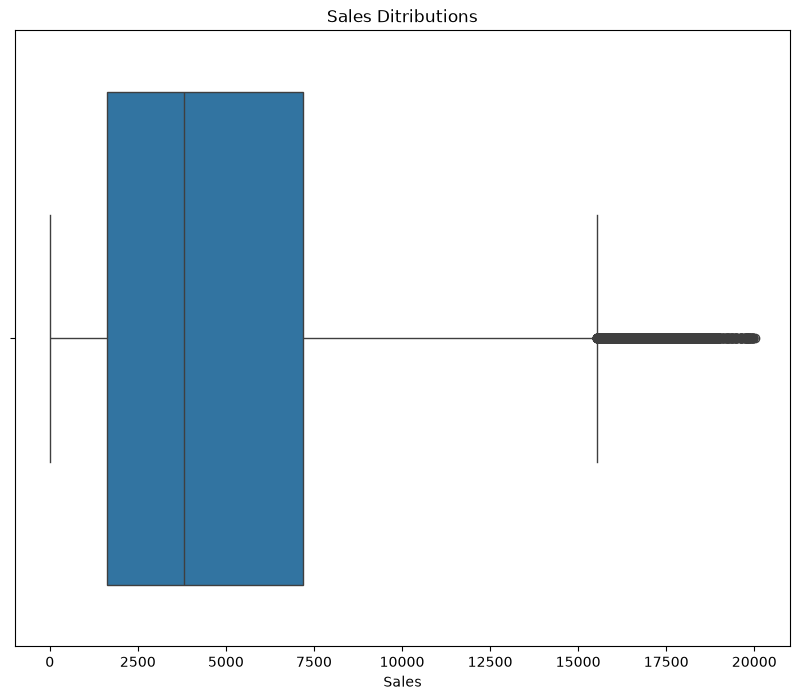

In [26]:
# Sales Distribution using barplot
plt.figure(figsize=(10,8))
plt.title('Sales Ditributions')
snp.boxplot(x=df['Sales'])
plt.show()

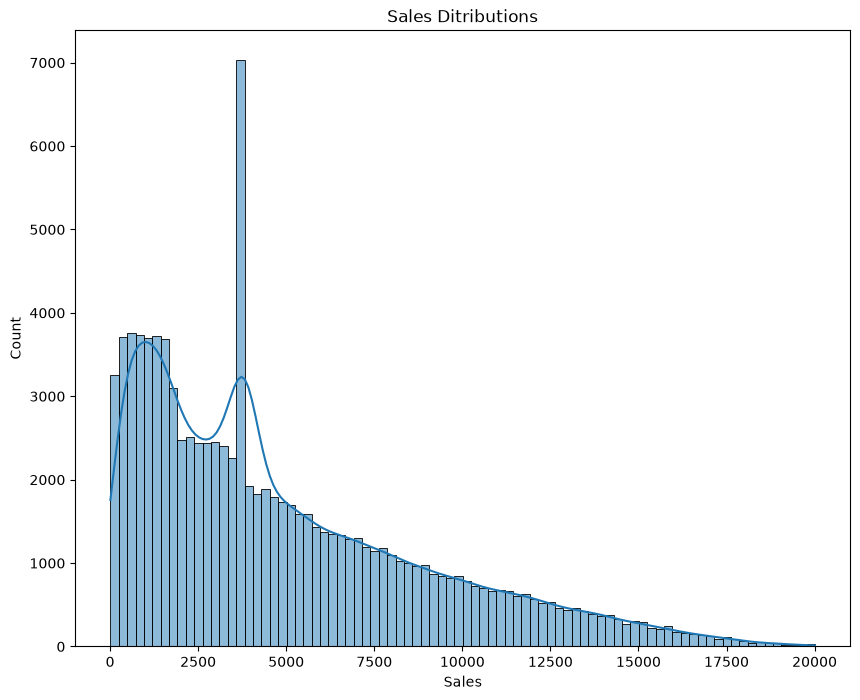

In [27]:
# Sales Distribution using histplot
plt.figure(figsize=(10,8))
plt.title('Sales Ditributions')
snp.histplot(df['Sales'],kde=True)
plt.show()

In [31]:
print("skewness",df['Sales'].skew())
print("kurtosis",df['Sales'].kurt())
state,p=shapiro(df['Sales'])
print("p-value",p)

skewness 1.0376104163984374
kurtosis 0.4341440093920319
p-value 5.453777163872226e-112


C:\Users\DIPAK\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 100000.
  res = hypotest_fun_out(*samples, **kwds)


#### 2.3 Correlation analysis 

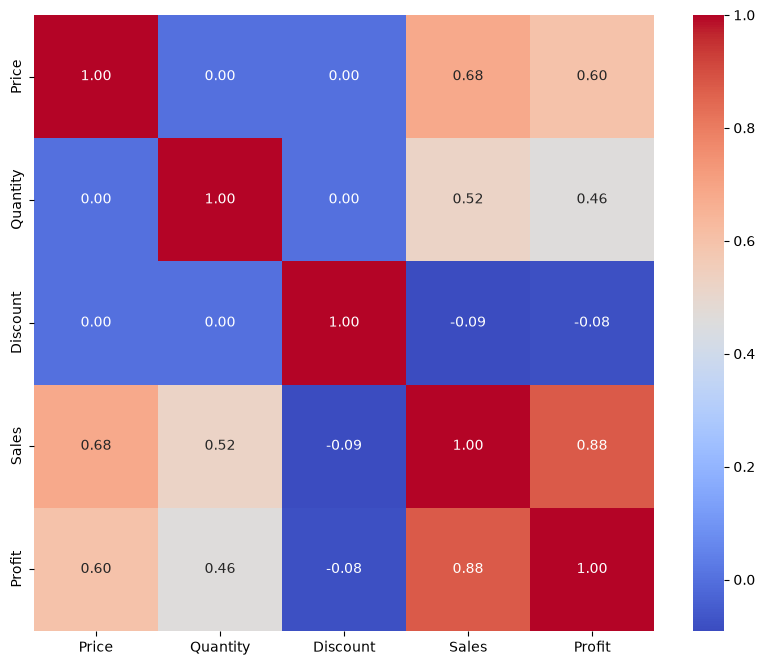

In [29]:
plt.figure(figsize=(10,8))
snp.heatmap(df.corr(method='pearson',numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')
plt.show()
#correl=df.corr(method='pearson',numeric_only=True).round(2)
#print(correl)

#### 2.4 Trend analysis

In [57]:
df['Month']=df['Order_Date'].dt.month
x=df[['Month']]
y=df[['Price']]

model=LinearRegression()
model.fit(x,y)

pred=model.predict(x)
print(pred)


[[1006.87220292]
 [1007.05587951]
 [1006.68852632]
 ...
 [1007.4232327 ]
 [1007.6069093 ]
 [1007.05587951]]


In [ ]:
#df.to_csv(r"D:\Cleandata.csv",index=False)